In [30]:
""" ▶ SINGLE MEASUREMENT STERN-GERLACH EXPERIMENT ◀ """

' ▶ SINGLE MEASUREMENT STERN-GERLACH EXPERIMENT ◀ '

In [31]:
""" MEASRUE RIGHT AFTER PASSING TROUGH A AG OVEN """
import random
from numpy import pi
import numpy as np

a = random.random()
b = random.random()
norm = np.sqrt(a * np.conjugate(a) + b * np.conjugate(b))  # = a^2 + b^2

#NORMALIZATION
a = a / norm
b = b / norm
print(a, b)

0.7258625872234632 0.6878397374892354


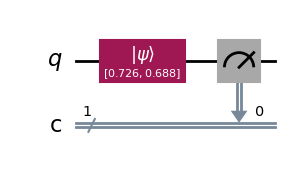

In [32]:
from qiskit.circuit import QuantumRegister, ClassicalRegister, QuantumCircuit, Parameter

# Define registers
qr = QuantumRegister(1, "q") # AG
cr = ClassicalRegister(1, "c") # SCREEN
qc = QuantumCircuit(qr, cr)

# Initialize the quantum state
qc.initialize([a, b])
qc.measure(0, 0)
qc.draw("mpl")

In [33]:
from qiskit_ibm_runtime import QiskitRuntimeService
service = QiskitRuntimeService()

from qiskit_ibm_runtime import Session, SamplerV2 as Sampler
backend = service.least_busy()
print(backend.name)

from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
qc_ibm = pm.run(qc)

num_shots = 1

qiskit_runtime_service.__init__:WARNING:2026-07-17 11:31:10,533: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: seolwon64. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-07-17 11:31:11,048: Using instance: seolwon64, plan: open


ibm_fez


In [34]:
# FOR AerSimulator
# from qiskit_aer import AerSimulator

# This generates a simulator that mimics the real quantum system
# backend_sim = AerSimulator.from_backend(backend)

# Import an estimator, this time from qiskit (we import from Runtime for real hardware)
# from qiskit.primitives import BackendSamplerV2
# sampler = BackendSamplerV2(backend = backend_sim)

# num_shots = 1

# This runs the job
# dist = sampler.run([qc_ibm], shots = num_shots).result()

# This selects measurement counts for the 0th circuit, which in this case is the only circuit
# counts=dist[0].data.c.get_counts()

In [35]:
from qiskit.visualization import plot_histogram

print("counts = ", counts)
plot_histogram(counts)

NameError: name 'counts' is not defined